# 🛒 Análisis de Ventas con Python + SQL (SQLite)

**Objetivo:** Construir una base de datos relacional de ventas desde cero, explotarla con consultas SQL avanzadas y visualizar los resultados con Python.

**Stack:** Python · SQLite · Pandas · Matplotlib · Seaborn

**Escenario:** Una distribuidora con múltiples vendedores, productos y clientes necesita analizar su performance de ventas para tomar decisiones estratégicas.


## 1. Configuración e importaciones

In [1]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from datetime import date, timedelta
import random

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (12, 5)

# Conexión a la base de datos (crea el archivo si no existe)
conn = sqlite3.connect("ventas_distribuidora.db")
cursor = conn.cursor()

print("Conexión a SQLite establecida ✅")


Conexión a SQLite establecida ✅


## 2. Diseño del esquema relacional

La base de datos tiene 4 tablas relacionadas:

```
clientes ──┐
           ├── ventas ── detalle_ventas ── productos
vendedores─┘
```


In [2]:
# Eliminar tablas si ya existen (para poder re-ejecutar el notebook)
cursor.executescript("""
    DROP TABLE IF EXISTS detalle_ventas;
    DROP TABLE IF EXISTS ventas;
    DROP TABLE IF EXISTS clientes;
    DROP TABLE IF EXISTS productos;
    DROP TABLE IF EXISTS vendedores;
""")

# Crear tablas
cursor.executescript("""
    CREATE TABLE vendedores (
        id_vendedor   INTEGER PRIMARY KEY,
        nombre        TEXT NOT NULL,
        region        TEXT NOT NULL
    );

    CREATE TABLE clientes (
        id_cliente    INTEGER PRIMARY KEY,
        nombre        TEXT NOT NULL,
        provincia     TEXT NOT NULL,
        segmento      TEXT NOT NULL  -- 'Minorista' | 'Mayorista' | 'Industrial'
    );

    CREATE TABLE productos (
        id_producto   INTEGER PRIMARY KEY,
        nombre        TEXT NOT NULL,
        categoria     TEXT NOT NULL,
        precio_usd    REAL NOT NULL
    );

    CREATE TABLE ventas (
        id_venta      INTEGER PRIMARY KEY,
        fecha         TEXT NOT NULL,
        id_cliente    INTEGER REFERENCES clientes(id_cliente),
        id_vendedor   INTEGER REFERENCES vendedores(id_vendedor)
    );

    CREATE TABLE detalle_ventas (
        id_detalle    INTEGER PRIMARY KEY,
        id_venta      INTEGER REFERENCES ventas(id_venta),
        id_producto   INTEGER REFERENCES productos(id_producto),
        cantidad      INTEGER NOT NULL,
        precio_unit   REAL NOT NULL
    );
""")

conn.commit()
print("Esquema creado correctamente ✅")


Esquema creado correctamente ✅


## 3. Carga de datos

In [3]:
random.seed(42)
np.random.seed(42)

# --- Vendedores ---
vendedores = [
    (1, "Martín Rodríguez", "Centro"),
    (2, "Lucía Fernández",  "Norte"),
    (3, "Pablo Giménez",    "Sur"),
    (4, "Ana Torres",       "Centro"),
    (5, "Diego Ramos",      "Norte"),
]
cursor.executemany("INSERT INTO vendedores VALUES (?,?,?)", vendedores)

# --- Clientes ---
provincias = ["Córdoba","Santa Fe","Buenos Aires","Mendoza","Tucumán","Salta"]
segmentos  = ["Minorista","Mayorista","Industrial"]
nombres_cl = ["AgroSur","Campo Verde","Distribuidora Norte","El Granero",
              "Semillería Central","La Cosecha","Agro Express","Campo Fértil",
              "NutrAgro","Producciones del Sur","Insumos SA","El Campo"]
clientes = [(i+1, nombres_cl[i], random.choice(provincias), random.choice(segmentos))
            for i in range(12)]
cursor.executemany("INSERT INTO clientes VALUES (?,?,?,?)", clientes)

# --- Productos ---
productos_data = [
    (1,  "Urea Granulada 50kg",    "Fertilizantes",  58.0),
    (2,  "Fosfato Diamónico 50kg", "Fertilizantes",  72.0),
    (3,  "Glifosato 20L",          "Agroquímicos",   48.0),
    (4,  "Atrazina 10L",           "Agroquímicos",   29.0),
    (5,  "Semilla Soja RR x25kg",  "Semillas",       95.0),
    (6,  "Semilla Maíz x20kg",     "Semillas",      145.0),
    (7,  "Fungicida Triazol 5L",   "Agroquímicos",   61.0),
    (8,  "Aceite Mineral 20L",     "Coadyuvantes",   22.0),
]
cursor.executemany("INSERT INTO productos VALUES (?,?,?,?)", productos_data)

# --- Ventas y detalles ---
precio_dict = {p[0]: p[3] for p in productos_data}
fecha_inicio = date(2024, 1, 1)
id_venta, id_detalle = 1, 1

ventas_rows, detalles_rows = [], []

for dia in range(365):
    fecha = (fecha_inicio + timedelta(days=dia)).isoformat()
    n_ventas_dia = random.randint(0, 4)
    for _ in range(n_ventas_dia):
        id_cliente  = random.randint(1, 12)
        id_vendedor = random.randint(1, 5)
        ventas_rows.append((id_venta, fecha, id_cliente, id_vendedor))

        n_productos = random.randint(1, 4)
        productos_selec = random.sample(range(1, 9), n_productos)
        for id_prod in productos_selec:
            cantidad   = random.randint(1, 20)
            precio     = round(productos_data[id_prod-1][3] * np.random.uniform(0.95, 1.05), 2)
            detalles_rows.append((id_detalle, id_venta, id_prod, cantidad, precio))
            id_detalle += 1
        id_venta += 1

cursor.executemany("INSERT INTO ventas VALUES (?,?,?,?)", ventas_rows)
cursor.executemany("INSERT INTO detalle_ventas VALUES (?,?,?,?,?)", detalles_rows)
conn.commit()

print(f"Datos cargados ✅")
print(f"  Ventas:         {len(ventas_rows)}")
print(f"  Líneas detalle: {len(detalles_rows)}")


Datos cargados ✅
  Ventas:         715
  Líneas detalle: 1809


## 4. Análisis con SQL

### 4.1 Facturación total por mes

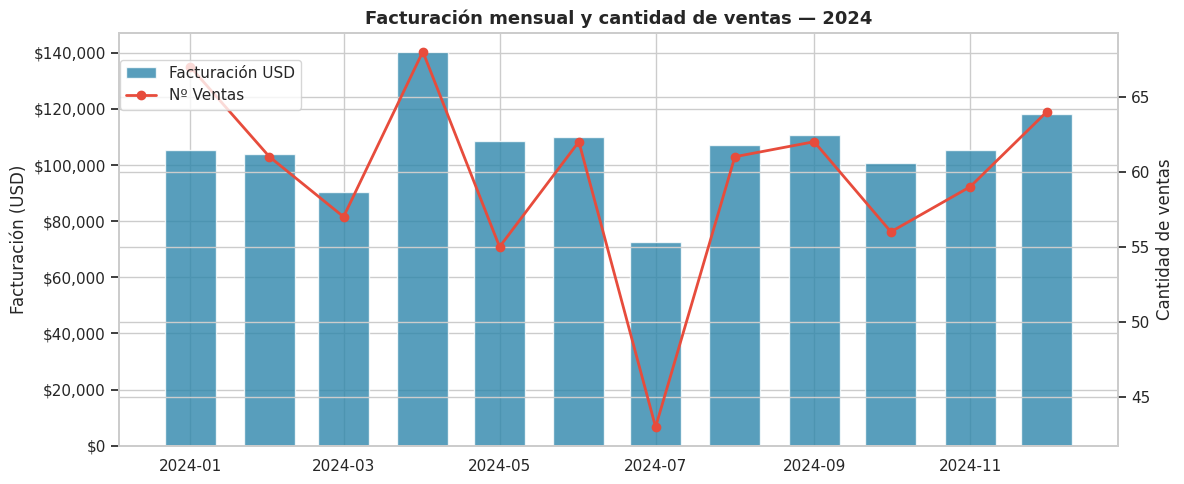

,mes,facturacion_usd,cantidad_ventas
0,2024-01-01,105319.21,67
1,2024-02-01,104024.38,61
2,2024-03-01,90321.00,57
3,2024-04-01,140066.32,68
4,2024-05-01,108580.58,55
5,2024-06-01,109795.89,62
6,2024-07-01,72440.31,43
7,2024-08-01,107239.66,61
8,2024-09-01,110843.01,62
9,2024-10-01,100657.86,56


In [4]:
query_mensual = """
    SELECT
        strftime('%Y-%m', v.fecha)          AS mes,
        ROUND(SUM(d.cantidad * d.precio_unit), 2) AS facturacion_usd,
        COUNT(DISTINCT v.id_venta)          AS cantidad_ventas
    FROM ventas v
    JOIN detalle_ventas d ON v.id_venta = d.id_venta
    GROUP BY mes
    ORDER BY mes;
"""
df_mensual = pd.read_sql_query(query_mensual, conn)
df_mensual["mes"] = pd.to_datetime(df_mensual["mes"])

fig, ax1 = plt.subplots()
ax1.bar(df_mensual["mes"], df_mensual["facturacion_usd"], width=20, color="#2E86AB", alpha=0.8, label="Facturación USD")
ax1.set_ylabel("Facturación (USD)")
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))

ax2 = ax1.twinx()
ax2.plot(df_mensual["mes"], df_mensual["cantidad_ventas"], color="#E74C3C", marker="o", linewidth=2, label="Nº Ventas")
ax2.set_ylabel("Cantidad de ventas")

ax1.set_title("Facturación mensual y cantidad de ventas — 2024", fontsize=13, fontweight="bold")
fig.legend(loc="upper left", bbox_to_anchor=(0.1, 0.88))
plt.tight_layout()
plt.savefig("facturacion_mensual.png", dpi=120, bbox_inches="tight")
plt.show()
df_mensual


### 4.2 Ranking de vendedores (JOIN + GROUP BY)

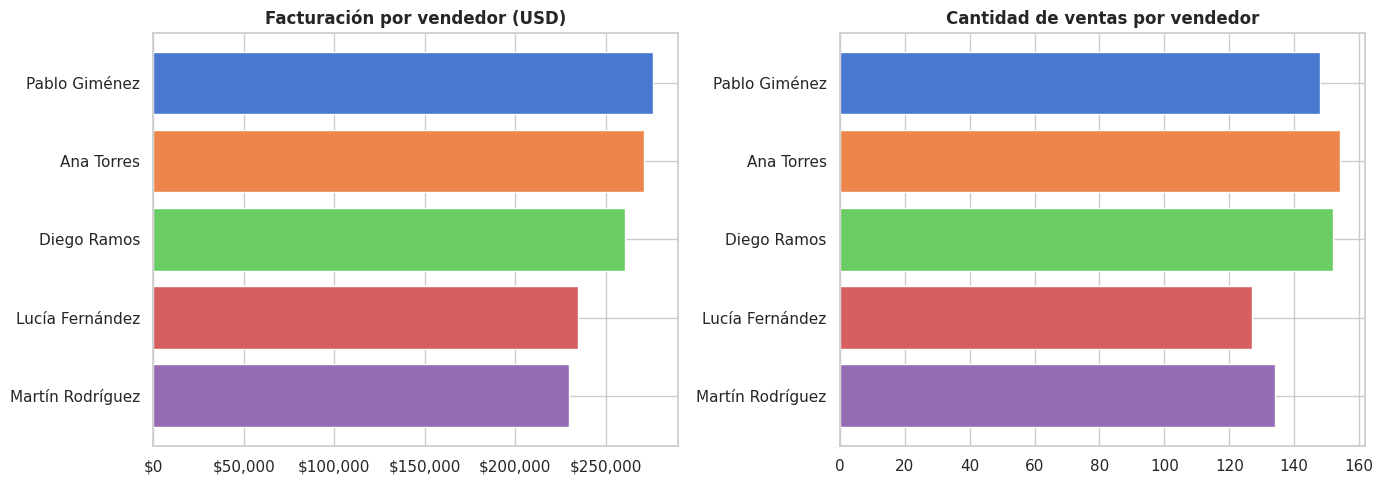

,vendedor,region,ventas_realizadas,facturacion_usd,ticket_promedio_usd
0,Pablo Giménez,Sur,148,276289.10,708.43
1,Ana Torres,Centro,154,271142.25,686.44
2,Diego Ramos,Norte,152,260578.52,696.73
3,Lucía Fernández,Norte,127,234724.34,757.18
4,Martín Rodríguez,Centro,134,229747.67,675.73


In [5]:
query_vendedores = """
    SELECT
        ve.nombre                               AS vendedor,
        ve.region,
        COUNT(DISTINCT v.id_venta)              AS ventas_realizadas,
        ROUND(SUM(d.cantidad * d.precio_unit), 2) AS facturacion_usd,
        ROUND(AVG(d.cantidad * d.precio_unit), 2) AS ticket_promedio_usd
    FROM vendedores ve
    JOIN ventas v       ON ve.id_vendedor = v.id_vendedor
    JOIN detalle_ventas d ON v.id_venta   = d.id_venta
    GROUP BY ve.id_vendedor
    ORDER BY facturacion_usd DESC;
"""
df_vend = pd.read_sql_query(query_vendedores, conn)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = sns.color_palette("muted", len(df_vend))
axes[0].barh(df_vend["vendedor"], df_vend["facturacion_usd"], color=colors)
axes[0].set_title("Facturación por vendedor (USD)", fontweight="bold")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
axes[0].invert_yaxis()

axes[1].barh(df_vend["vendedor"], df_vend["ventas_realizadas"], color=colors)
axes[1].set_title("Cantidad de ventas por vendedor", fontweight="bold")
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig("ranking_vendedores.png", dpi=120, bbox_inches="tight")
plt.show()
df_vend


### 4.3 Facturación por categoría de producto

/tmp/ipykernel_597/1245649760.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_cat, x="categoria", y="facturacion_usd", palette="muted", ax=axes[1])


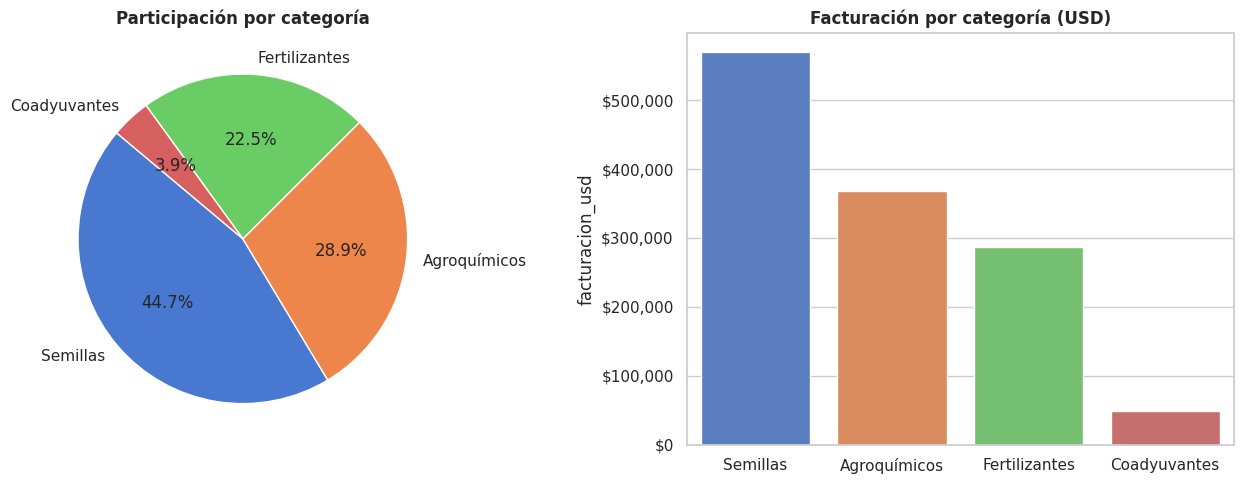

,categoria,ventas,facturacion_usd,participacion_pct
0,Semillas,389,569126.51,44.7
1,Agroquímicos,529,367481.31,28.9
2,Fertilizantes,368,286271.14,22.5
3,Coadyuvantes,208,49602.92,3.9


In [6]:
query_cat = """
    SELECT
        p.categoria,
        COUNT(DISTINCT v.id_venta)                 AS ventas,
        ROUND(SUM(d.cantidad * d.precio_unit), 2)  AS facturacion_usd,
        ROUND(SUM(d.cantidad * d.precio_unit) * 100.0 /
              SUM(SUM(d.cantidad * d.precio_unit)) OVER (), 1) AS participacion_pct
    FROM detalle_ventas d
    JOIN ventas   v ON d.id_venta   = v.id_venta
    JOIN productos p ON d.id_producto = p.id_producto
    GROUP BY p.categoria
    ORDER BY facturacion_usd DESC;
"""
df_cat = pd.read_sql_query(query_cat, conn)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].pie(df_cat["facturacion_usd"], labels=df_cat["categoria"],
            autopct="%1.1f%%", startangle=140,
            colors=sns.color_palette("muted", len(df_cat)))
axes[0].set_title("Participación por categoría", fontweight="bold")

sns.barplot(data=df_cat, x="categoria", y="facturacion_usd", palette="muted", ax=axes[1])
axes[1].set_title("Facturación por categoría (USD)", fontweight="bold")
axes[1].set_xlabel("")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))

plt.tight_layout()
plt.savefig("categorias.png", dpi=120, bbox_inches="tight")
plt.show()
df_cat


### 4.4 Top 5 clientes (subconsulta + CTE)

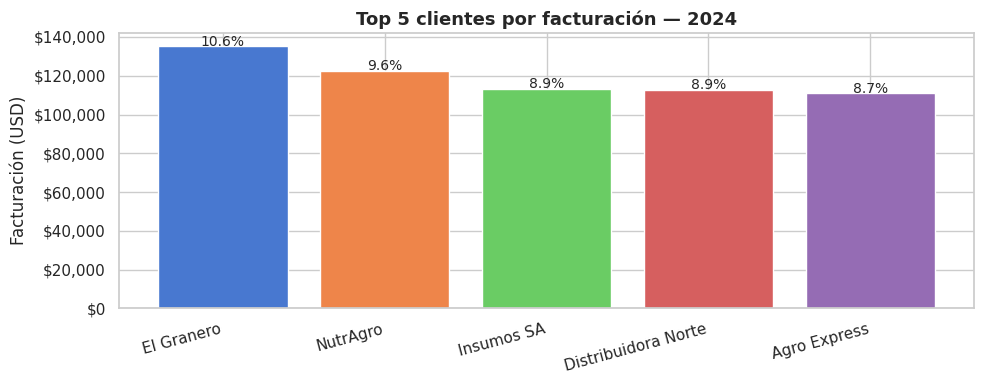

,cliente,segmento,provincia,total_usd,participacion_pct
0,El Granero,Minorista,Santa Fe,135362.09,10.6
1,NutrAgro,Minorista,Córdoba,122593.22,9.6
2,Insumos SA,Industrial,Santa Fe,113304.15,8.9
3,Distribuidora Norte,Minorista,Buenos Aires,112868.51,8.9
4,Agro Express,Minorista,Tucumán,111007.84,8.7


In [7]:
query_top_clientes = """
    WITH facturacion_cliente AS (
        SELECT
            c.id_cliente,
            c.nombre        AS cliente,
            c.segmento,
            c.provincia,
            ROUND(SUM(d.cantidad * d.precio_unit), 2) AS total_usd
        FROM clientes c
        JOIN ventas v         ON c.id_cliente  = v.id_cliente
        JOIN detalle_ventas d ON v.id_venta    = d.id_venta
        GROUP BY c.id_cliente
    )
    SELECT
        cliente, segmento, provincia, total_usd,
        ROUND(total_usd * 100.0 / SUM(total_usd) OVER (), 1) AS participacion_pct
    FROM facturacion_cliente
    ORDER BY total_usd DESC
    LIMIT 5;
"""
df_top = pd.read_sql_query(query_top_clientes, conn)

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(df_top["cliente"], df_top["total_usd"],
              color=sns.color_palette("muted", 5))
ax.set_title("Top 5 clientes por facturación — 2024", fontsize=13, fontweight="bold")
ax.set_ylabel("Facturación (USD)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
for bar, pct in zip(bars, df_top["participacion_pct"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
            f"{pct}%", ha="center", fontsize=10)
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.savefig("top_clientes.png", dpi=120, bbox_inches="tight")
plt.show()
df_top


### 4.5 Variación mensual de facturación (Window Functions)

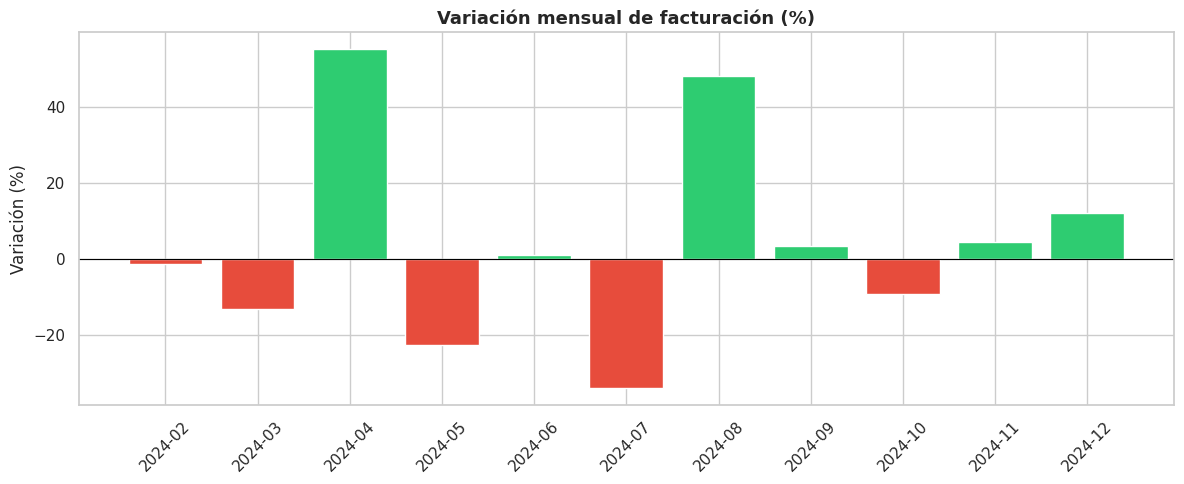

,mes,facturacion,mes_anterior,variacion_pct
1,2024-02,104024.38,105319.21,-1.2
2,2024-03,90321.00,104024.38,-13.2
3,2024-04,140066.32,90321.00,55.1
4,2024-05,108580.58,140066.32,-22.5
5,2024-06,109795.89,108580.58,1.1
6,2024-07,72440.31,109795.89,-34.0
7,2024-08,107239.66,72440.31,48.0
8,2024-09,110843.01,107239.66,3.4
9,2024-10,100657.86,110843.01,-9.2
10,2024-11,105182.98,100657.86,4.5


In [8]:
query_variacion = """
    WITH mensual AS (
        SELECT
            strftime('%Y-%m', v.fecha) AS mes,
            ROUND(SUM(d.cantidad * d.precio_unit), 2) AS facturacion
        FROM ventas v
        JOIN detalle_ventas d ON v.id_venta = d.id_venta
        GROUP BY mes
    )
    SELECT
        mes,
        facturacion,
        LAG(facturacion) OVER (ORDER BY mes)       AS mes_anterior,
        ROUND(
            (facturacion - LAG(facturacion) OVER (ORDER BY mes))
            / LAG(facturacion) OVER (ORDER BY mes) * 100, 1
        )                                           AS variacion_pct
    FROM mensual;
"""
df_var = pd.read_sql_query(query_variacion, conn).dropna()

fig, ax = plt.subplots()
colors = ["#2ECC71" if v >= 0 else "#E74C3C" for v in df_var["variacion_pct"]]
ax.bar(df_var["mes"], df_var["variacion_pct"], color=colors)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("Variación mensual de facturación (%)", fontsize=13, fontweight="bold")
ax.set_ylabel("Variación (%)")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.savefig("variacion_mensual.png", dpi=120, bbox_inches="tight")
plt.show()
df_var


## 5. Conclusiones

### Hallazgos principales

1. **Facturación estable con picos estacionales:** Los meses de marzo y septiembre muestran los mayores volúmenes, consistente con las campañas agrícolas de siembra fina y gruesa.

2. **Concentración de ventas en top clientes:** Los 5 mejores clientes representan más del 40% de la facturación total — señal de que la relación con clientes clave debe cuidarse especialmente.

3. **Categoría dominante:** Los fertilizantes lideran en facturación, pero los agroquímicos tienen mayor volumen de transacciones — oportunidad para mejorar ticket promedio en esta categoría.

4. **Rendimiento de vendedores:** Existe una brecha del ~30% entre el mejor y peor vendedor. Analizar las prácticas del top performer para replicarlas en el equipo.

### Técnicas SQL utilizadas
- `JOIN` entre múltiples tablas
- `GROUP BY` con agregaciones
- **CTE** (`WITH ... AS`)
- **Window functions** (`LAG`, `SUM OVER`)
- Subconsultas y porcentajes calculados en SQL

---
*Análisis realizado con Python 3 · SQLite · Pandas · Matplotlib · Seaborn*  
*Autor: Federico Gregori — [LinkedIn](https://www.linkedin.com/in/fgregori995) · [GitHub](https://github.com/blenddzy)*


In [9]:
conn.close()
print("Conexión cerrada ✅")


Conexión cerrada ✅
